In [ ]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar el dataset de ventas de videojuegos
df = pd.read_csv("../data/videogames_sales_1980_2016.csv")

In [ ]:
# Vista de las primeras filas
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Resumen de estructura, tipos y nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       7590 non-null   float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(10), str(6)
memory usage: 2.0 MB


In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,7.125046,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,1.500006,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,6.400000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.500000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,8.200000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.700000,10665.000000


In [ ]:
# Agregar ventas globales por año de lanzamiento
ventas_por_anio = (
    df.groupby("Year_of_Release", dropna=True)["Global_Sales"]
      .sum()
      .reset_index()
      .sort_values("Year_of_Release")
)
# Vista previa de la tabla de ventas por año
ventas_por_anio.head()

,Year_of_Release,Global_Sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36


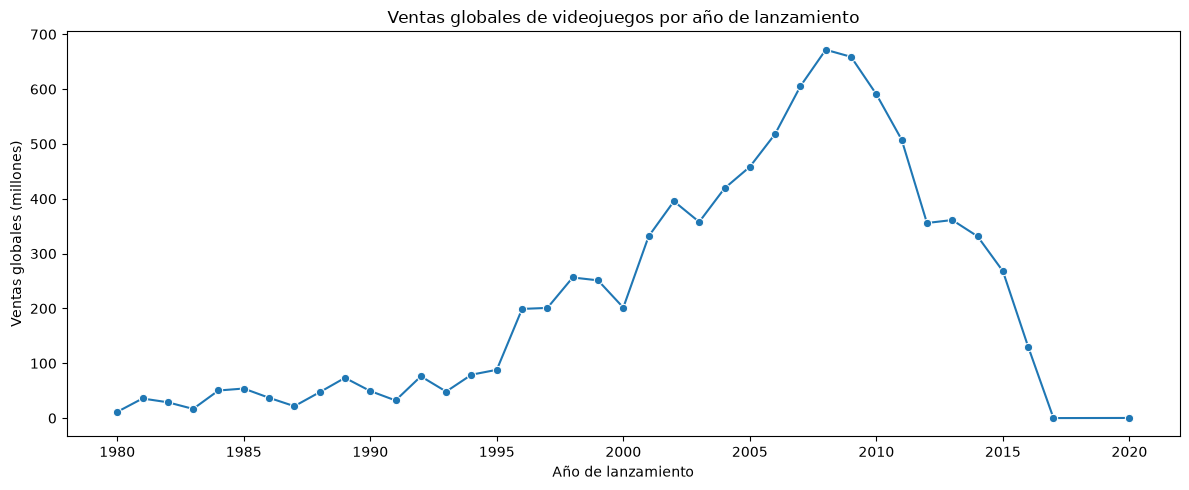

In [19]:
# Evolución temporal de las ventas globales por año
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=ventas_por_anio,
    x="Year_of_Release",
    y="Global_Sales",
    marker="o"
)
plt.title("Ventas globales de videojuegos por año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas globales (millones)")
plt.tight_layout()

In [20]:
# Ranking de plataformas por ventas globales (top 10)
ventas_por_plataforma = (
    df.groupby("Platform")["Global_Sales"]
      .sum()
      .reset_index()
      .sort_values("Global_Sales", ascending=False)
)

ventas_por_plataforma.head(10)

,Platform,Global_Sales
16,PS2,1255.64
28,X360,971.63
17,PS3,939.43
26,Wii,908.13
4,DS,807.10
15,PS,730.68
6,GBA,318.50
18,PS4,314.23
19,PSP,294.30
13,PC,260.30


In [ ]:
# Ranking de géneros por ventas globales
ventas_por_genero = (
    df.groupby("Genre")["Global_Sales"]
      .sum()
      .reset_index()
      .sort_values("Global_Sales", ascending=False)
)

ventas_por_genero

,Genre,Global_Sales
0,Action,1745.27
10,Sports,1332.00
8,Shooter,1052.94
7,Role-Playing,934.40
4,Platform,828.08
3,Misc,803.18
6,Racing,728.90
2,Fighting,447.48
9,Simulation,390.42
5,Puzzle,243.02


In [21]:
# Conteo de valores nulos por columna (ordenado de mayor a menor)
df.isna().sum().sort_values(ascending=False)

User_Score         9129
User_Count         9129
Critic_Score       8582
Critic_Count       8582
Rating             6769
Developer          6623
Year_of_Release     269
Publisher            54
Name                  2
Genre                 2
NA_Sales              0
Platform              0
JP_Sales              0
EU_Sales              0
Other_Sales           0
Global_Sales          0
dtype: int64

In [22]:
# Preparar subconjunto numérico para correlaciones
numericas = df[[
    "Global_Sales",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Critic_Score",
    "User_Score",
    "Critic_Count",
    "User_Count"
]]
corr = numericas.corr()
corr


,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Critic_Score,User_Score,Critic_Count,User_Count
Global_Sales,1.000000,0.941010,0.901239,0.612300,0.245471,0.088139,0.303571,0.265012
NA_Sales,0.941010,1.000000,0.765336,0.449598,0.240755,0.086200,0.295413,0.246429
EU_Sales,0.901239,0.765336,1.000000,0.435068,0.220752,0.055337,0.277533,0.283360
JP_Sales,0.612300,0.449598,0.435068,1.000000,0.152593,0.125598,0.180219,0.075638
Critic_Score,0.245471,0.240755,0.220752,0.152593,1.000000,0.580878,0.425504,0.264376
User_Score,0.088139,0.086200,0.055337,0.125598,0.580878,1.000000,0.194133,0.027044
Critic_Count,0.303571,0.295413,0.277533,0.180219,0.425504,0.194133,1.000000,0.362334
User_Count,0.265012,0.246429,0.283360,0.075638,0.264376,0.027044,0.362334,1.000000


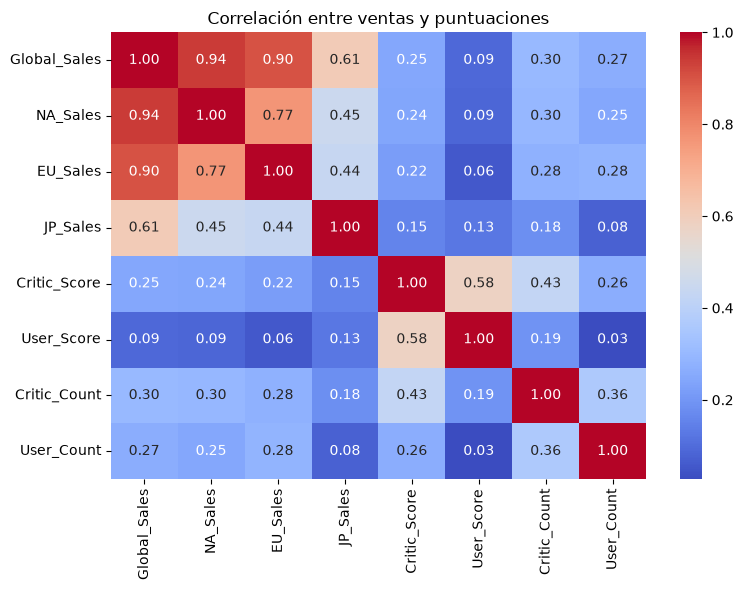

In [16]:
# Visualizar la matriz (para luego llevarla al dashboard)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlación entre ventas y puntuaciones")
plt.tight_layout()


In [17]:
# Porcentajes de nulos por columna
nulos_porcentaje = (df.isna().mean() * 100).round(1)
nulos_porcentaje.sort_values(ascending=False)


User_Score         54.6
User_Count         54.6
Critic_Score       51.3
Critic_Count       51.3
Rating             40.5
Developer          39.6
Year_of_Release     1.6
Publisher           0.3
JP_Sales            0.0
EU_Sales            0.0
NA_Sales            0.0
Genre               0.0
Name                0.0
Platform            0.0
Other_Sales         0.0
Global_Sales        0.0
dtype: float64

### Calidad de datos y sesgos del dataset

- Más del 50 % de los juegos no tiene `User_Score` ni `User_Count`, y tampoco tiene `Critic_Score` ni `Critic_Count`. Cualquier análisis que relacione ventas con valoraciones se basa solo en la mitad del catálogo, probablemente los títulos más visibles.
- Alrededor del 40 % de los registros carece de `Rating` y `Developer`, limitando la capacidad para analizar el impacto de la clasificación por edades o del desarrollador en las ventas.
- `Year_of_Release` tiene pocos valores nulos, sin embargo la serie temporal muestra un pico de ventas entre 2005 y 2009 y una caída fuerte a partir de 2010 a 2016. Esto me lleva a la conclusión de que el dataset está centrado en las ventas físicas históricas y no captura bien el crecimiento de la distribución digital reciente.